# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE)

## Notebook P2-03: UBFC-Phys Preprocessing

### What this notebook does

This notebook preprocesses the **UBFC-Phys dataset* into a unified HDF5 format compatible with all other datasets in the QualityPhys pipeline.

UBFC-Phys sits between UBFC-rPPG and ECG-Fitness in terms of difficulty:
- More realistic than UBFC-rPPG - three different task conditions per subject
- Less challenging than ECG-Fitness - no physical exercise, controlled lab setting
- Unique in the corpus - the only dataset with **psychological stress labels** and **three distinct physiological states** per subject in the same session

Key characteristics:
- Videos are standard uncompressed **8-bit RGB** - same conversion as UBFC-rPPG
- Ground truth is **wrist BVP** form a wristband sensor - noiser than fingertip PPG (UBFC-rPPG) and less accurate than ECG (ECG-Fitness) for HRV computation
- Three tasks per subject create distinc physiological states: T1 (rest) -> T2 (speach/social stress) -> T3 (arithmetic/cognitive stress)
- The task label is a valuable conditioning signal for stress-aware models

### Why wrist BVP is less reliable than fingertip PPG

Peripheral perfusion varies between body sites. The wrist has a more complex motion environment than the fingertip (wrist flexion, arm movements) and the contact pressure of the wristband changes with movement. This introduces motion artefacts into the BVP signal that are absent from a properly placed finger clip oxmimeter. HRV metrics derived from wrist BVP carry higher uncertainty than from fingertip PPG, which in turn carries higher uncertainty than from fingertip PPG, which in turn carries higher uncertainty than from ECG. This is reflected in the metadata: `reference_type: PPG_wrist` carries the lowest HRV confidence weight of all dataset in the corpus.

### Known dataset limitations

12 participants were eliminated from the original 68 due to technical problems or data sharing refusal - the released dataset has 56 subjects.

Some subjects pressed the wristband button during recording, which creates a brief artefact in the BVP signal. The SQI layer will catch and flag clips where this produces implausible RR intervals.

The BVP sampling rate is not perfectly constant - it varies slightly between subjects. 

### Dataset structure 

```
UBFC-Phys/
└── s1/                    <- subjects s1 to s56
    ├── vid_s1_T1.avi      <- rest task video
    ├── vid_s1_T2.avi      <- speech task video
    ├── vid_s1_T3.avi      <- arithmetic task video
    ├── bvp_s1_T1.csv      <- wrist BVP during rest
    ├── bvp_s1_T2.csv      <- wrist BVP during speech
    └── bvp_s1_T3.csv      <- wrist BVP during arithmetic
```
**Note**: EDA (electrodermal activity) files are present in some versions of the dataset but are not used in this pipeline.

### Pipeline

```
vid_sN_TX.avi (BGR decoded by OpenCV)
    │
    ├─ 1. BGR -> RGB 
    ├─ 2. MediaPipe Face Mesh -> ROI masks (forehead, cheeks)
    └─ 3. Spatial mean RGB per ROI -> [T, 3_ROIs, 3_ch]
           │
           └─ 4. Bandpass 0.7–3.5 Hz -> POS -> rPPG signal [T]

bvp_sN_TX.csv (wrist BVP signal)
    │
    ├─ 5. Estimate BVP sampling rate from timestamps
    ├─ 6. Resample BVP to video FPS using np.interp
    ├─ 7. PPG peak detection (NeuroKit2 nk.ppg_peaks)
    └─ 8. Compute HR, RR intervals, RMSSD, SDNN, pNN50

9. Signal Quality Index - rPPG SQI + BVP SQI
10. Discard recordings below quality threshold
11. Write continuous signals to HDF5 with task label
```

## 1. Environment Setup

In [1]:
import subprocess, sys

packages = [
    "neurokit2", 
    "mediapipe",
    "h5py", 
    "opencv-python",
    "scipy", 
    "numpy",
    "pandas",
    "matplotlib"
    ]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packeges installed")

All packeges installed


## 2. Imports and Configuration 

**Key differences from UBFC-rPPG configuration:**

- `TASK` defines the three recording conditions per subject
- `TASK_NAMES` defines the three recording conditions per subject
- `BVP_SQI_THRESHOLD` is separate from `RPPG_SQI_THRESHOLD` because the wrist BVP reference signal has its own quality assessment
- `reference_type` will be `PPG_wrist` - lower HRV confidence than `PPG_finger` or `ECG`

**Key differences from ECG-Fitness configuration:**
- No `ECG_BP_LOW` / `ECG_BP_HIGH` - no ECG signal in this dataset
- No `MIN_BRIGHTNESS` - no outdoor or variable lighting sessions
- No `VALID_ACTIVITIES` filtering - all three tasks are included
- BVP sampling rate is estimated per-recording, not fixed globally

In [2]:
import os, warnings, cv2, h5py, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from scipy.signal import butter, filtfilt

warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color" : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color" : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})

# Paths 
UBFC_PHYS_DIR = "F:/UBFC_PHYS"
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset identity
DATASET_NAME = "ubfc_phys"
HDF5_PATH = os.path.join(OUTPUT_DIR, "ubfc_phys.h5")

# Task configuration
# Three tasks per subject, each creating a distinct physiological state.

TASKS = ["T1", "T2", "T3"]
TASK_NAMES = {
    "T1" : "rest", # baseline resting state
    "T2" : "speech", # social stress - public speaking task
    "T3" : "arithmetic", # cognitive stress - mental arithmetic
}

# Signal processing parameters
FPS = 35.0 # UBFC-Phys video frame rate
BVP_FS_NOMINAL = 64.0 # UBFC-Phys sampling rate


# rPPG bandpass: 0.7 - 3.5 Hz = 42-210 BPM - same as all notebooks 
RPPG_BP_LOW = 0.7
RPPG_BP_HIGH = 3.5

# BVP bandpass applied to the wrist reference signal before peak detection
# Same as UBFC-rPPG PPG bandpass - preserves systolic peak morphology
BVP_BP_LOW = 0.5
BVP_BP_HIGH = 8.0


# Signal Quality Index thresholds
# Two separate thresholds: one for the rPPG signal, one for the BVP reference.
# UBFC-Phys wrist BVP is noisier than UBFC-rPPG fingertip PPG.
# The BVP SQI threshold is lower (0.3) to account for this - a higher threshold would discard
# too many valid recordings because of wrist noise rather than genuine signal failure
RPPG_SQI_THRESHOLD = 0.4 
BVP_SQI_THRESHOLD = 0.3 

# ROI landmark indices (MediaPipe Face Mesh, 468-point model)
FOREHEAD_LM = [10, 338, 297, 332, 284, 251, 389, 356, 454,
                  323, 361, 288, 397, 365, 379, 378, 400, 377,
                  152, 148, 176, 149, 150, 136, 172, 58, 132,
                  93, 234, 127, 162, 21, 54, 103, 67, 109]

LEFT_CHEEK_LM = [234, 227, 116, 123, 147, 213, 192, 214, 210,
                 211, 206, 203, 36, 101, 119, 229, 228]

RIGHT_CHEEK_LM = [454, 447, 345, 352, 376, 433, 416, 434, 430,
                  431, 426, 423, 266, 330, 348, 449, 448]

ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek" : RIGHT_CHEEK_LM
}

print("Configuration loaded.")
print(f"Dataset path: {UBFC_PHYS_DIR}")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"Output path : {OUTPUT_DIR}")
print(f"Tasks : {TASKS} {TASK_NAMES}")
print(f"rPPG bandpass: {RPPG_BP_LOW}-{RPPG_BP_HIGH} Hz ({RPPG_BP_LOW*60:.0f}-{RPPG_BP_HIGH*60:.0f} BPM)")
print(f"BVP bandpass : {BVP_BP_LOW}-{BVP_BP_HIGH} Hz")
print(f"rPPG SQI threshold : {RPPG_SQI_THRESHOLD}")
print(f"BVP SQI threshold : {BVP_SQI_THRESHOLD}")


Configuration loaded.
Dataset path: F:/UBFC_PHYS
Output HDF5 : E:/QualityPhys\ubfc_phys.h5
Output path : E:/QualityPhys
Tasks : ['T1', 'T2', 'T3'] {'T1': 'rest', 'T2': 'speech', 'T3': 'arithmetic'}
rPPG bandpass: 0.7-3.5 Hz (42-210 BPM)
BVP bandpass : 0.5-8.0 Hz
rPPG SQI threshold : 0.4
BVP SQI threshold : 0.3


## 3. Dataset Scan

UBFC-Phys has a regular structure: one folde per subject named `s1` to `s56`, with six files inside each folder - one video and one BVP CSV per task.

Te scan checks all six files exist for each subject-task combination and builds an inventory with one row per recording (subject x task). A recording is marked complete only if both its video and BVP file are present.

In [3]:
def scan_ubfc_phys(root_dir: str, tasks: list) -> pd.DataFrame:
    """
    Walk the UBFC-Phys directory and build a per-recording inventory.

    Returns a DataFrame with one row per (subject, task) combination.
    Subject folders are named s1 to s56.
    """
    records = []

    for folder in sorted(os.listdir(root_dir), key=lambda x: int(x[1:]) if x[1:].isdigit() else 0):
        folder_path = os.path.join(root_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        if not folder.startswith("s") or not folder[1:].isdigit():
            continue

        subject_id = int(folder[1:])

        for task in tasks:
            # File naming convention: vid_sN_TX.avi and bvp_sN_TX.csv
            video_path = os.path.join(folder_path, f"vid_{folder}_{task}.avi")
            bvp_path = os.path.join(folder_path, f"bvp_{folder}_{task}.csv")

            has_video = os.path.exists(video_path)
            has_bvp = os.path.exists(bvp_path)

            records.append({
                "subject_id" : subject_id,
                "subject_folder" : folder,
                "task" : task,
                "task_name" : TASK_NAMES.get(task, "unknown"),
                "video_path" : video_path if has_video else None,
                "bvp_path" : bvp_path if has_bvp else None,
                "complete" : has_video and has_bvp,
            })
    return pd.DataFrame(records).sort_values(["subject_id", "task"]).reset_index(drop=True)

df_inventory = scan_ubfc_phys(UBFC_PHYS_DIR, TASKS)

complete = df_inventory["complete"].sum()
incomplete = (~df_inventory["complete"]).sum()

print(f"Recordings found : {len(df_inventory)}")
print(f"Complete : {complete}")
print(f"Incomplete : {incomplete}")
print(f"Expected complete: 56 subjects x 3 tasks = 168")
print()
print("Per-task summary:")
print(df_inventory.groupby("task")["complete"].sum().to_string())
print()
print(df_inventory[["subject_id", "task", "task_name", "complete"]].head(15).to_string(index=False))

Recordings found : 168
Complete : 167
Incomplete : 1
Expected complete: 56 subjects x 3 tasks = 168

Per-task summary:
task
T1    56
T2    56
T3    55

 subject_id task  task_name  complete
          1   T1       rest      True
          1   T2     speech      True
          1   T3 arithmetic      True
          2   T1       rest      True
          2   T2     speech      True
          2   T3 arithmetic      True
          3   T1       rest      True
          3   T2     speech      True
          3   T3 arithmetic      True
          4   T1       rest      True
          4   T2     speech      True
          4   T3 arithmetic      True
          5   T1       rest      True
          5   T2     speech      True
          5   T3 arithmetic      True


## 4. Load and Inspect BVP Reference Signal

### The UBFC-Phys BVP CSV format

Each `bvp_sN_TX.csv` file contains two columns.
- Colum 0: BVP amplitude values (blood volume pulse from wirstband)
- Column 1: Timestamps in seconds

The file has no header row. The BVP sampling rate is not fixed - it is estimated from the actual timestamps for each recording individually. 

### What wrist BVP looks like versus fingertip PPG

From your clinical background: fingertip PPG has a clean, sharp systolic peak because the finger has dense superficial capillaries and minimal volountary movement during a resting recording. Wrist BVP has the same fundamental shape but with more baseline noise because:
- The wrist flexors and extensors are active even during "rest"
- The wristband contact pressure changes with subtle arm movements
- The wrist has a deeper vascular bed than the fingertip

The systolic peaks are still detectable but less sharp - NeuroKit2's `ppg_peaks()` handles this well, but expect lower peak detection confidence than with fingertip PPG.

### Why duration varies between tasks

T1 (rest) is approximately 3 minutes. T2 (speech) and T3 (arithmetic) are also approximately 3 minutes, but subjects were allowed to finish naturally rather than being cut off at a fixed time. Duration variations of ±30  seconds between tasks and subjects is expected.




Inspecting subject 1, task T1 (rest)

BVP loaded: 11520 samples at 64 Hz 180.0 s


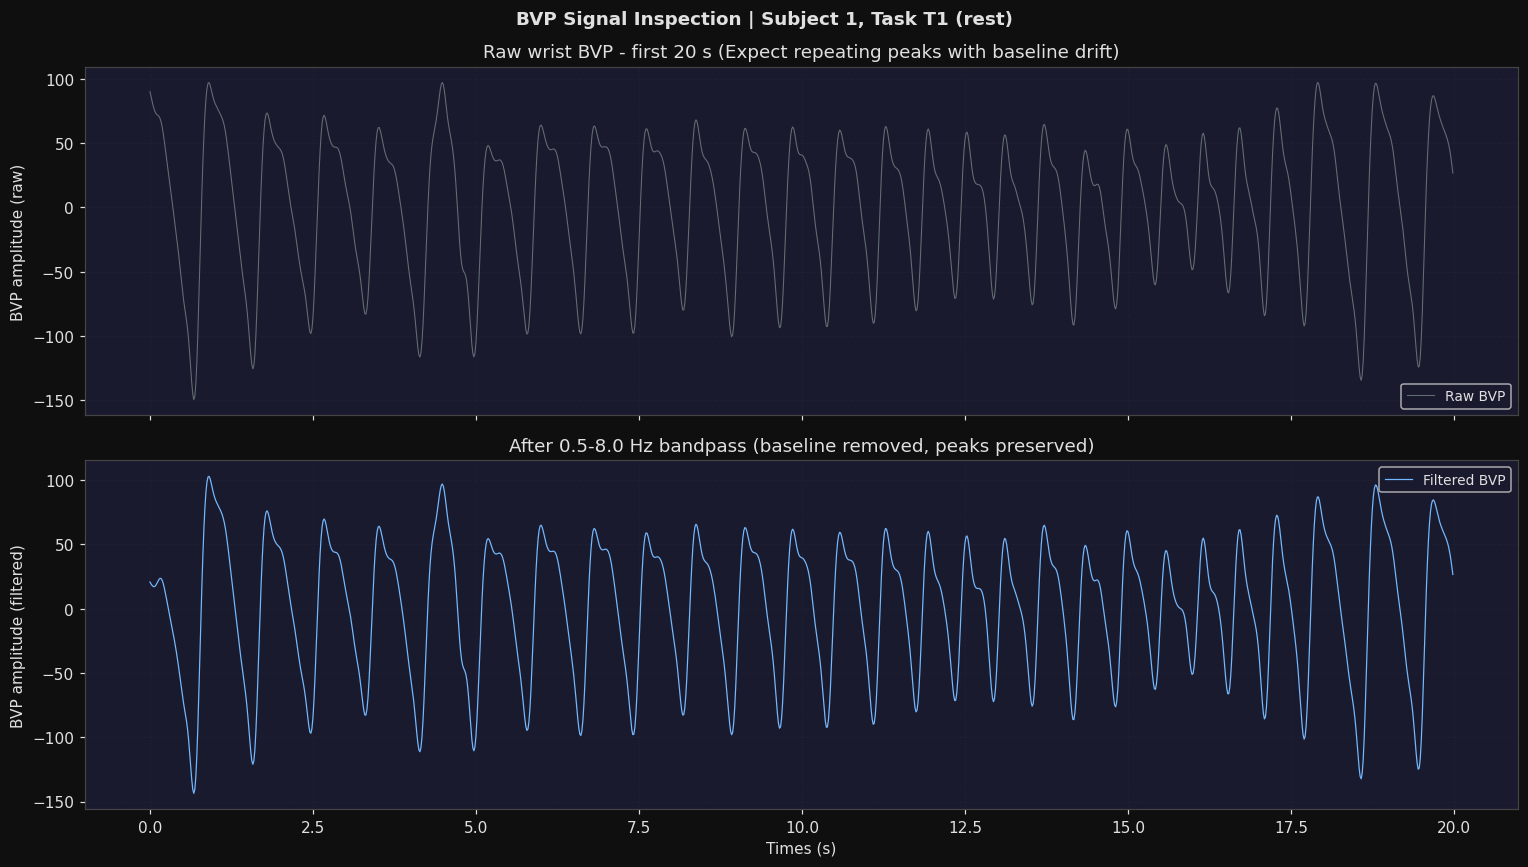

BVP sampling rate : 64.0 Hz
BVP duration : 180.0 s
Signal amplitude : 612.59
Signal amplitude OK


In [4]:
def bandpass_filter(signal: np.ndarray, fs: float, low: float, high: float, order: int = 2) -> np.ndarray:
    """
    Zero-phase Butterworth bandpass filter.

    Zero-phase (filtfilt) preserves peak timing - critical for accurate
    RR interval and HRV computation. Shared across all QualityPhys notebooks.

    Args:
        signal : 1D array
        fs : sampling frequency in Hz
        low : sampling cutoff in Hz
        high: upper cutoff in Hz
        order: filter order (2 = gentle, avoids ringing artefacts)
    """
    nyq = fs / 2.0
    b, a  = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal).astype(np.float32)

    
def load_bvp(bvp_path: str) -> dict:
    """
    Load a UBFC-Phys BPV CSV file.

    UBFC_Phys format: single column, no header, no timestamps.
    Values are raw BVP amplitude sampled at 64 Hz.
    Sampling rate is taken from dataset documentation - the file 
    contains no timing information to estimate it from.
    """
    df = pd.read_csv(bvp_path, header=None)

    bvp_raw = df.iloc[:, 0].values.astype(np.float32)

    # Build synthetic timestamp array from nominal sampling rate
    # This is used only for duration reporting - signal alignment
    # uses resample_to_fps which operates on sample counts, no timestamps

    timestamps = np.arange(len(bvp_raw)) / BVP_FS_NOMINAL

    print(f"BVP loaded: {len(bvp_raw)} samples at {BVP_FS_NOMINAL:.0f} Hz {len(bvp_raw)/BVP_FS_NOMINAL:.1f} s")

    return {
        "bvp_raw" : bvp_raw,
        "timestamps" : timestamps,
        "bvp_fs" : BVP_FS_NOMINAL
    }


def inspect_bvp(bvp_path: str, subject_id: int, task: str) -> dict:
    """
    Load and visually inspect the BVP signal for one recording.

    Plots:
        1. Raw BVP waveform - check for detectable pulse shape
        2. Filtered BVP - verify filtering preserves peaks while removing baseline wander

    What a usable wrist BVP looks like:
        - Repeating peaks visible, thougj less sharp than fingertip PPG
        - Some baseline drift acceptable - filtered out in processing
        - No completely flat sections (wristband disconnection)
        - No sustained clipping at max/min values (saturation)
    """
    bvp_data = load_bvp(bvp_path)
    bvp = bvp_data["bvp_raw"]
    ts = bvp_data["timestamps"]
    fs = bvp_data["bvp_fs"]

    # Filter for visualisation
    bvp_filtered = bandpass_filter(bvp, fs, BVP_BP_LOW, BVP_BP_HIGH)

    # Show first 20 seconds
    n_show = int(fs * 20)
    t = ts[:n_show] - ts[0] # normalise to start at 0

    fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)
    fig.suptitle(f"BVP Signal Inspection | Subject {subject_id}, Task {task} ({TASK_NAMES.get(task, '')})",
                 fontsize=12, fontweight="bold")

    axes[0].plot(t, bvp[: n_show], color="#636e72", lw=0.7, label="Raw BVP")
    axes[0].set_ylabel("BVP amplitude (raw)")
    axes[0].set_title("Raw wrist BVP - first 20 s (Expect repeating peaks with baseline drift)")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, bvp_filtered[:n_show], color="#74b9ff", lw=0.8, label="Filtered BVP")
    axes[1].set_ylabel("BVP amplitude (filtered)")
    axes[1].set_xlabel("Times (s)")
    axes[1].set_title(f"After {BVP_BP_LOW}-{BVP_BP_HIGH} Hz bandpass (baseline removed, peaks preserved)")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/bvp_inspect_s{subject_id:02d}_{task}.png",
                 bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    # Amplutde check - flat signal means wristband disconnection
    amplitude_range = bvp.max() - bvp.min()
    print(f"BVP sampling rate : {fs:.1f} Hz")
    print(f"BVP duration : {len(bvp)/fs:.1f} s")
    print(f"Signal amplitude : {amplitude_range:.2f}")

    if amplitude_range < 0.01:
        print("WARNING : near flat BVP - possible wristband disconnection")
    else:
        print("Signal amplitude OK")

    return bvp_data


# Run on first complete recording
first_rec = df_inventory[df_inventory["complete"]].iloc[0]
print(f"Inspecting subject {first_rec.subject_id}, task {first_rec.task} ({first_rec.task_name})")
print()
bvp_demo = inspect_bvp(first_rec["bvp_path"], first_rec["subject_id"], first_rec["task"])
        

## 5. Signal Processing  - Filter, Peaks, HRV

The BVP processing pipeline mirrors the UBFC-rPPG PPG pipeline exactly:
bandpass filter -> `nk.ppg_clean()` -> `nk.ppg_peaks()` -> RR intervals -> HRV.

The key difference is the reference signal quality. Wrist BVP peaks are broader and noisier than fingertip PPG peaks, which means:
- Peak timing precision is lower (~5-10 ms vs ~2-3 ms for fingertip PPG)
- RMSSD computed from wrist BVP has higher uncertainty
- pNN50 is particularly sensitive to this timing error - use with caution

These are dataset-level constraints, not pipeline failures. The metadata field `reference_type : PPG_wrist` flags this for the model training code.

The `resample_to_fps` function is identical to the UBFC-rPPG notebook - the BVP signal sampled at ~64 Hz must be resampled to 30 fps to align with video frames.

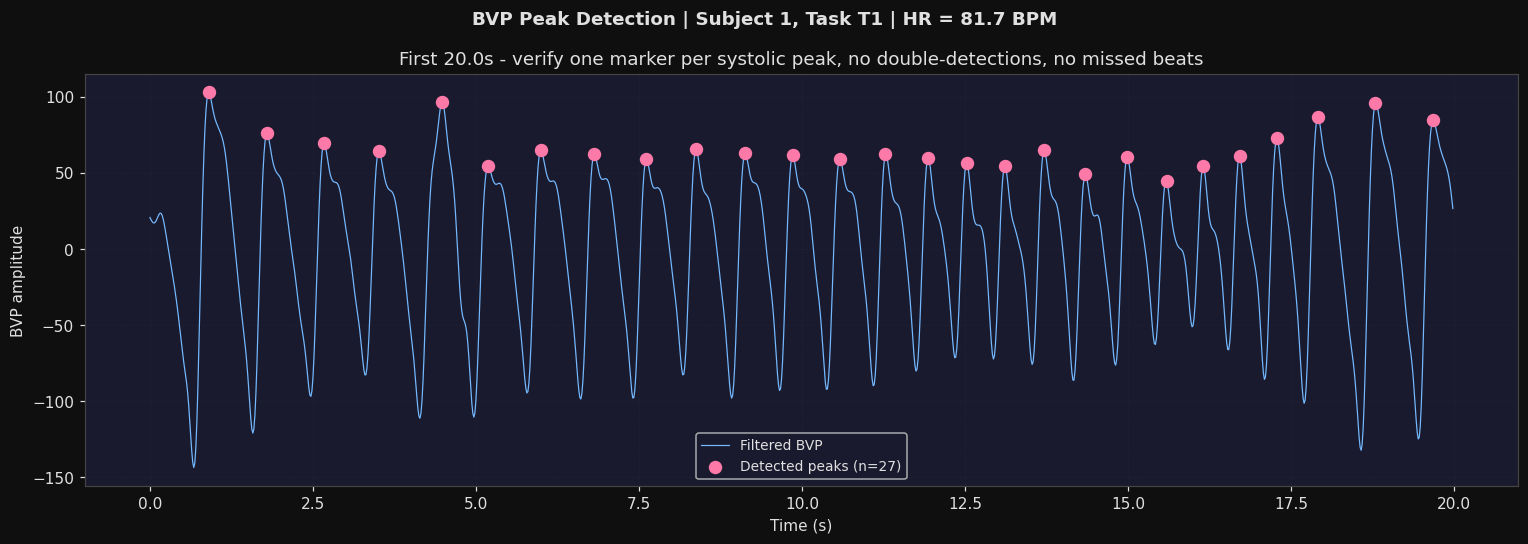

Detected HR : 81.7 BPM
Expected : 50-110 BPM for resting/cognitive stress task
HR within plausible range

HRV features:
RMSSD : 83.7 ms
SDNN : 118.1 ms
pNN50 : 21.5 %
HR mean: 81.7 BPM

Clinical note: RMSSD expected to decrease from T1->T2->T3
as sympathetic nervous system activation suppresses vagal tone


In [5]:
def resample_to_fps(signal: np.ndarray, original_fs: float, target_fps: float) -> np.ndarray:
    """
    Resample a signal from its original sampling rate to video FPS>

    Uses linear interpolation (np.interp) - same as UBFC-rPPG notebook.
    The output has one sample per video frame, so signal[k] corresponds directly to frame k.
    """
    n_original = len(signal)
    n_target = int(n_original * target_fps / original_fs)

    original_times = np.linspace(0, 1, n_original)
    target_times = np.linspace(0, 1, n_target)

    return np.interp(target_times, original_times, signal).astype(np.float32)


def detect_bvp_peaks(bvp_raw: np.ndarray, bvp_fs: float) -> tuple:
    """
    Detect systolic peaks in a wrist BVP signal.

    Pipeline: bandpass filter -> nk.ppg_clean() -> nk.ppg_peaks()

    Returns:
        peak_indices : sample indices of detected systolic peaks
        rr_ms : RR intervals in milliseconds
        hr_mean : mean HR in BPM
    """
    bvp_filtered = bandpass_filter(bvp_raw, bvp_fs, BVP_BP_LOW, BVP_BP_HIGH)
    bvp_clean = nk.ppg_clean(bvp_filtered, sampling_rate=int(bvp_fs))

    peaks_dict, _ = nk.ppg_peaks(bvp_clean, sampling_rate=int(bvp_fs))
    peak_indices = np.where(peaks_dict["PPG_Peaks"] == 1)[0]

    if len(peak_indices) < 3:
        return peak_indices, np.array([]), float("nan")

    rr_ms = np.diff(peak_indices) / bvp_fs * 1000.0 
    hr_mean = float(60000.0 / rr_ms.mean())

    return peak_indices, rr_ms, hr_mean

def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """
    Compute time-domain HRV features from RR intervals.

    Identical implementation across all QualityPhys notebooks.
    The unified output contract requires consistent HRV keys
    regardless of whether the source was ECG, fingertip PPG, or wrist BVP.

    Note: HRV metrics computed from wrist BVP carry higher uncertainty than 
    from fingertip PPG or ECG. 
    """
    nan_result = {
        "mean_rr_ms" : float("nan"),
        "sdnn_ms" : float("nan"),
        "rmssd_ms" : float("nan"),
        "pnn50_pct" : float("nan"),
        "hr_mean_bpm" : float("nan"),
        "hr_min_bpm" : float("nan"),
        "hr_max_bpm" : float("nan"),
    }

    if len(rr_ms) < 3:
        return nan_result

    # Remove physiologically imporrible RR intervals
    # <300 ms = HR > 200 BPM | > 2000 ms = HR < 30 BPM
    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]

    if len(rr_clean) < 3:
        return nan_result

    successive_diffs = np.diff(rr_clean)

    result = {
        "mean_rr_ms" : float(rr_clean.mean()),
        "sdnn_ms" : float(rr_clean.std()),
        "rmssd_ms" : float(np.sqrt(np.mean(successive_diffs ** 2))),
        "pnn50_pct" : float((np.abs(successive_diffs) > 50).mean() * 100),
        "hr_mean_bpm" : float(60000.0 / rr_clean.mean()),
        "hr_min_bpm" : float(60000.0 / rr_clean.max()),
        "hr_max_bpm" : float(60000.0 / rr_clean.min()),
    }
    return result

def validate_bvp_peaks(bvp_raw: np.ndarray, peak_indices: np.ndarray, hr_detected: float, bvp_fs: float, 
                       subject_id: int, task: str, window_sec: float = 20.0) -> None:
    """
    Visual validation of BVP peak detection.

    Plots detected peaks overlaid on the filtered BVP waveform.
    For UBFC-Phys there is no separate device HR to cross_check agains
    (inlike ECG-Fitness Viatom device HR or UBFC-rPPG ground truth HR).
    Validation is therefore visual only - check that peaks sit at 
    systolic maxima with no double-detection or missed beats.
    """
    bvp_filtered = bandpass_filter(bvp_raw, bvp_fs, BVP_BP_LOW, BVP_BP_HIGH)
    n_show = int(window_sec * bvp_fs)
    t = np.arange(n_show) / bvp_fs
    peaks_in_window = peak_indices[peak_indices < n_show]

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"BVP Peak Detection | Subject {subject_id}, Task {task} | HR = {hr_detected:.1f} BPM",
                 fontsize=12, fontweight="bold")
    ax.plot(t, bvp_filtered[:n_show], color="#74b9ff", lw=0.8, label="Filtered BVP")
    if len(peaks_in_window) > 0:
        ax.scatter(peaks_in_window / bvp_fs, bvp_filtered[peaks_in_window], color="#fd79a8",
                   s=60, zorder=5, label=f"Detected peaks (n={len(peaks_in_window)})")
    ax.set_ylabel("BVP amplitude")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"First {window_sec}s - verify one marker per systolic peak, no double-detections, no missed beats")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/bvp_peaks_s{subject_id:02}_{task}.png", bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print(f"Detected HR : {hr_detected:.1f} BPM")
    print(f"Expected : 50-110 BPM for resting/cognitive stress task")
    if 40 < hr_detected < 130:
        print("HR within plausible range")
    else:
        print("HR outside expected range - check peak detection visually")


# Run on demo recording
bvp_raw_demo = bvp_demo["bvp_raw"]
bvp_fs_demo = bvp_demo["bvp_fs"]

peak_indices_demo, rr_ms_demo, hr_mean_demo = detect_bvp_peaks(bvp_raw_demo, bvp_fs_demo)

validate_bvp_peaks(bvp_raw_demo, peak_indices_demo, hr_mean_demo, bvp_fs_demo, first_rec["subject_id"], first_rec["task"])

hrv_demo = compute_hrv_features(rr_ms_demo)
print()
print("HRV features:")
print(f"RMSSD : {hrv_demo['rmssd_ms']:.1f} ms")
print(f"SDNN : {hrv_demo['sdnn_ms']:.1f} ms")
print(f"pNN50 : {hrv_demo['pnn50_pct']:.1f} %")
print(f"HR mean: {hrv_demo['hr_mean_bpm']:.1f} BPM")
print()
print("Clinical note: RMSSD expected to decrease from T1->T2->T3")
print("as sympathetic nervous system activation suppresses vagal tone")

## 6. Siqnal Quality Index (SQI)

UBFC-Phys uses **two SQI scores** per recording:

**rPPG SQI** - autocorrelation-based, identical to all other notebooks. Measures whether the extracted POS signal has a periodic component at the expected heartbeat frequency. Theshold: 0.4.

**BVP SQI** - R-peak regularity of the wrist BVP reference signal. Measures how regular the detected peak spacing is - the same coefficient of variation approach used for ECG SQI in the ECG-Fitness notebook. A lower threshold (0.3) is used because wrist BVP has inherently higher RR interval variability from motion artefact, even in valid recordings.

Both SQI scores must pass their respective thresholds for a recording to be included. If the BVP reference quality is too low, the HR and HRV labels cannot be trusted even if the rPPG signal is clean.

In [6]:
def compute_bvp_sqi(rr_ms: np.ndarray) -> float:
    """
    BVP Signal Quality Index based on RR interval regularity.

    Identical to compute_ecg_sqi() from ECG-Fitness notebook the coefficient
    of variation approach works for any peak-to-peak interval series regardless 
    of whether the source is ECG or PPG.

    Score = 1 - min(CV, 1.0)
        CV = std(RR) / mean(RR)
        CV near 0 -> highly regular -> SQI near 1.0
        CV near 1 -> highly irregular -> SQI near 0.0

    Threshold is lower than ECG SQI (0.3 vs 0.5) because wrist BVP has naturally higher
    RR variability from motion even in clean recordings.
    """
    if len(rr_ms) < 3:
        return float("nan")

    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_clean) < 3:
        return float("nan")

    cv = rr_clean.std() / (rr_clean.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))


def compute_rppg_sqi(rppg_signal: np.ndarray, hr_bpm: float, fs: float = FPS) -> float:
    """
    rPPG Signal Quality Index - autocorrelation at expected HR lag.
    Identical implementation across all QualityPhys notebooks.
    Args:
        rppg_signal : POS-extracted signal, bandpass filtered and z-scored
        hr_bpm : expected HR in BPM 
        fs : video sampling rate in fps
    """
    if hr_bpm <= 0 or np.isnan(hr_bpm):
        return float("nan")

    beat_period_samples = int(round(fs * 60.0 / hr_bpm))

    if beat_period_samples >= len(rppg_signal):
        return float("nan")

    s = rppg_signal - rppg_signal.mean()
    autocorr_zero = np.dot(s,s)
    if autocorr_zero < 1e-10:
        return 0.0

    autocorr_lag = np.dot(s[:-beat_period_samples], s[beat_period_samples:])
    sqi = float(autocorr_lag / autocorr_zero)
    return float(max(0.0, min(sqi, 1.0)))

# Demo SQI
bvp_sqi_demo = compute_bvp_sqi(rr_ms_demo)

print(f"BVP SQI for demo recording : {bvp_sqi_demo:.3f}")
print(f"BVP SQI threshold : {BVP_SQI_THRESHOLD}")
if bvp_sqi_demo >= BVP_SQI_THRESHOLD:
    print("BVP quality acceptable - recording would be kept")
else:
    print("BVP quality below threshold - recording would be discarded")

BVP SQI for demo recording : 0.839
BVP SQI threshold : 0.3
BVP quality acceptable - recording would be kept


## 7. rPPG Extraction (Video -> Signal)

Identical to the UBFC-rPPG notebook - standard BGR -> RGB conversion, MediaPipe face landmark detection, ROI spatial averaging, bandpass filter, POS method, z-score normalization.

UBFC-Phys videos are recorded with subjects seated at a desk in a lab setting. The camera is fixed. Face orientation should be consistently frontal for T1 and T3 tasks. For T2 (speach task) expect some head movement as subjects describe or discuss - similar to the speaking activity in ECG-Fitness which showed degraded rPPG SQI.


In [7]:
# Download MediaPipe face landmarker model if not present
MODEL_PATH =  "./face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = ("https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task")
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Downloaded.")
else:
    print("Face landmarker model already present.")


def get_roi_mask(landmarks, frame_shape: tuple, landmark_indices: list) -> np.ndarray:
    """
    Build binary polygon mask for one ROI from landmark indices.
    """
    h, w = frame_shape[:2]
    pts = np.array([[int(landmarks[idx].x * w), int(landmarks[idx].y * h)] for idx in landmark_indices], dtype=np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def extract_roi_signals(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Extract spatially-average RGB time series from facial ROIs.

    Identical to the UBFC-rPPG version - standard BGR -> RGB conversion.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    roi_sigs = {name: [] for name in roi_configs}
    n_frames = 0
    no_face_ct = 0

    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            # Standard BGR -> RGB 
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            ts_ms = int((n_frames / fps) * 1000)
            result = landmarker.detect_for_video(mp_image, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb_frame.shape, indices)
                    if mask.sum() > 0:
                        r = rgb_frame[:, :, 0][mask == 1].mean()
                        g = rgb_frame[:, :, 1][mask == 1].mean()
                        b = rgb_frame[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r, g, b], dtype=np.float32))
                    else:
                        fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fallback)
            else:
                no_face_ct += 1
                for name in roi_configs:
                    fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fallback)
            
            n_frames += 1

    cap.release()
    result_dict = {name: np.array(values) for name, values in roi_sigs.items()}
    result_dict["__fps__"] = fps
    result_dict["__n_frames__"] = n_frames
    result_dict["__no_face_pct__"] = round(100 * no_face_ct / max(n_frames, 1), 1)
    return result_dict

def extract_pos(clip_roi: dict) -> np.ndarray:
    """
    POS method averaged across all ROIs.
    Identical across all QualityPhys notebooks.
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float64)
    roi_names = [k for k in clip_roi if not k.startswith("__")]
    signals = []

    for name in roi_names:
        C = clip_roi[name].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8))* S[1]
        signals.append(h)

    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, FPS, RPPG_BP_LOW, RPPG_BP_HIGH)

    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)

print("rPPG extraction functions defined.")

Face landmarker model already present.
rPPG extraction functions defined.


## 8. Full Pipeline  - Single Recording

Run the complete pipeline on one subject-task combination and verify every output before processing the full dataset.

**Note on HR upper limit**: The HR upper limit is set to 150 BPM - lower than UBFC-rPPG (180 BPM) and much lower than ECG-Fitness (220 BPM). UBFC-Phys subject experience psychological stress, not physical exertion. Sustained HR above 150 BPM would be exceptional for a cognitive stress task and likely indicates a peak detection error rather than a genuine physiological response.

In [8]:
def process_single_recording(video_path: str, bvp_path: str, subject_id: int, task: str, max_frames: int = None) -> tuple:
    """
    Run the full preprocessing pipeline on one UBFC-Phys recording.

    Returns a tuple of (result_dict, reason string). 
    result_dict is None if the recording was skipped.
    reason_string is "ok" on success or describes the skip reason.

    Key differences from ECG-Fitness and UBFC-rPPG:
        - BVP loaded from CSV (not ground_truth.txt or viatom-raw.csv)
        - BVP sampling rate estimated per-recording (not fixed)
        - Both rPPG SQI and BVP SQI must pass their respective thresholds
        - Task label stored in metadata - valuable for stress-aware training
        - HR upper limit 150 BPM (cognitive stress, not physical exercise)
    """
    # Step 1: Load BVP reference signal
    bvp_data = load_bvp(bvp_path)
    bvp_raw = bvp_data["bvp_raw"]
    bvp_fs = bvp_data["bvp_fs"]

    # Flat signal check - nearzero amplitude means wristband diconnection
    if bvp_raw.max() - bvp_raw.min() < 0.01:
        print(f"SKIP s{subject_id:02d}/{task}: flat BVP signal (wristband disconnection?)")
        return None, "flat_bvp_signal"

    # Step 2: Detect BVP peaks + compute HR and HRV
    peak_indices, rr_ms, hr_mean = detect_bvp_peaks(bvp_raw, bvp_fs)

    # HR upper limit 150 BPM - cognitive stress task, no physical exercise
    if np.isnan(hr_mean) or hr_mean < 40 or hr_mean > 150:
        print(f"SKIP s{subject_id:02d}/{task}: implausible HR ({hr_mean:.1f} BPM)")
        return None, f"implausible_hr ({hr_mean:.1f} BPM)"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: BVP SQI - check reference signal quality
    bvp_sqi = compute_bvp_sqi(rr_ms)
    if bvp_sqi < BVP_SQI_THRESHOLD:
        print(f"SKIP s{subject_id:02d}/{task}: BVP SQI too low ({bvp_sqi:.3f})")
        return None, f"bvp_sqi_low ({bvp_sqi:.3f})"

    # Step 4: Resample BVP to video FPS for frame alignment
    bvp_resampled = resample_to_fps(bvp_raw, bvp_fs, FPS)

    # Step 5: Extract rPPG signal from video
    roi_data = extract_roi_signals(video_path, ROI_CONFIGS, max_frames=max_frames)
    n_frames = roi_data["__n_frames__"]
    no_face = roi_data["__no_face_pct__"]

    if no_face > 20.0:
        print(f"SKIP s{subject_id:02d}/{task}: too many frames without face ({no_face:.1f}%)")
        return None, f"no_face ({no_face:.1f}%)"

    rppg_signal = extract_pos(roi_data)

    # Stack ROI RGB: [T, 3_ROIs, 3_Ch]
    roi_names = [k for k in roi_data if not k.startswith("__")]
    roi_rgb = np.stack([roi_data[name] for name in roi_names], axis=1).astype(np.float32)

    # Step 6: rPPG SQI
    rppg_sqi = compute_rppg_sqi(rppg_signal, hr_mean, FPS)
    if rppg_sqi < RPPG_SQI_THRESHOLD:
        print(f"SKIP s{subject_id:02d}/{task}: rPPG SQI too low ({rppg_sqi:.3f})")
        return None, f"rppg_sqi_low ({rppg_sqi:.3f})"

    # Step 7: Align all signals to shortest common length
    T = min(len(rppg_signal), len(bvp_resampled), roi_rgb.shape[0])
    rppg_signal = rppg_signal[:T]
    bvp_resampled = bvp_resampled[:T]
    roi_rgb = roi_rgb[:T]

    # Compute continuous HR array by interpolating from peak timing
    hr_continuous = np.full(T, np.nan, dtype=np.float32)
    if len(rr_ms) >= 2:
        # Map each peak index to video frame index
        peak_frames = (peak_indices / bvp_fs * FPS).astype(int)
        peak_frames = peak_frames[peak_frames < T]

        for j, frame_i in enumerate(peak_frames[:-1]):
            if j < len(rr_ms):
                hr_continuous[frame_i] = 60000.0 / rr_ms[j]
        # Forward-fill for frames between peaks
        last_hr = np.nan
        for i in range(T):
            if not np.isnan(hr_continuous[i]):
                last_hr = hr_continuous[i]
            elif not np.isnan(last_hr):
                hr_continuous[i] = last_hr
    
    print(f"s{subject_id:02d}/{task} ({TASK_NAMES.get(task, "")}) frames={T} HR={hr_mean:.1f} BVP_SQI={bvp_sqi:.2f} rPPG_SQI={rppg_sqi:.2f} no_face={no_face:.1f}%")

    result = {
        # Signals
        "rppg_signal" : rppg_signal, # [T] float32
        "roi_rgb" : roi_rgb, # [T, 3, 3] float32
        "reference_signal" : bvp_resampled, # [T] float32
        "hr_continuous" : hr_continuous, # [T] float32
        "rr_intervals" : rr_ms.astype(np.float32),

        # Scalar HRV labels
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],

        # Metadata 
        "subject_id" : subject_id,
        "activity_id" : task, # T1, T2, or T3
        "activity_name" : TASK_NAMES.get(task, "unknown"),
        "dataset" : DATASET_NAME,
        "reference_type" : "PPG_wrist", # lower HRV confidence than PPG_finger or ECG
        "n_frames" : T,
        "fps" : FPS,
        "bvp_sqi" : float(bvp_sqi),
        "rppg_sqi" : float(rppg_sqi),
        "no_face_pct" : float(no_face)
    }
    return result, "ok"

# Test on first recording - 300 frames (~10 s) for quick sanity check
print("Running single-recording pipeline test (first 300 frames)...")
demo_result, demo_reason = process_single_recording(
    first_rec["video_path"],
    first_rec["bvp_path"],
    first_rec["subject_id"],
    first_rec["task"],
    max_frames=300,
)

if demo_result is not None:
    print()
    print("Output shapes:")
    for key, value in demo_result.items():
        if hasattr(value, "shape"):
            print(f"{key:<20} : {value.shape}")
        elif isinstance(value, float):
            print(f"{key:<20} : {value:.3f}")
        else:
            print(f"{key:<20} : {value}")
else:
    print(f"Demo recording skipped - reason: {demo_reason}")

Running single-recording pipeline test (first 300 frames)...
BVP loaded: 11520 samples at 64 Hz 180.0 s
SKIP s01/T1: rPPG SQI too low (0.393)
Demo recording skipped - reason: rppg_sqi_low (0.393)


## 9. Write to HDF5

The HDF5 schema is consistent with all QualityPhys notebooks.
One addition specific to UBFC-Phys: `bvp_sqi` is stored as an attribute alongside `rppg_sqi`, because both quality scores are meaningful here and the model training code may want to weight samples by both.

The subject ID padding uses two digits (`subject_01`) to keep sorting consistent with ECG-Fitness (`subject_00` to `subject_16`).

In [9]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> None:
    """
    Write one preprocessed recording tp the HDF5 file.

    Identical structure to other QualityPhys notebooks. 
    Additional attribute: bvp_sqi (not present in UBFC-rPPG).
    Resume-safe: skips groups that already exist.
    """
    subj = f"{result['subject_id']:02d}"
    act = result["activity_id"]
    path = f"subjects/{subj}/recordings/{act}"

    if path in h5_file:
        print(f"Already exists: {path} - skipping")
        return

    grp = h5_file.require_group(path)

    grp.create_dataset("rppg_signal", data=result["rppg_signal"], compression="gzip", compression_opts=4)
    grp.create_dataset("roi_rgb", data=result["roi_rgb"], compression="gzip", compression_opts=4)
    grp.create_dataset("reference_signal", data=result["reference_signal"], compression="gzip", compression_opts=4)
    grp.create_dataset("hr_continuous", data=result["hr_continuous"], compression="gzip", compression_opts=4)
    grp.create_dataset("rr_intervals", data=result["rr_intervals"], compression="gzip", compression_opts=4)

    attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "rppg_sqi" : result["rppg_sqi"],
        "bvp_sqi" : result["bvp_sqi"], 
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in attrs.items():
        grp.attrs[key] = value


def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Create or open the HDF5 file with top-level metadata.

    Mode "a" = append - safe to reopen without losing existing data.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["fps"] = FPS
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["bvp_bp_low"] = BVP_BP_LOW
        meta.attrs["bvp_bp_high"] = BVP_BP_HIGH
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["bvp_sqi_threshold"]=  BVP_SQI_THRESHOLD
        meta.attrs["task"] = str(TASKS)

    return h5

# Write demo result
print(f"Writing to: {HDF5_PATH}")
if demo_result is not None:
    with initialise_hdf5(HDF5_PATH) as h5:
        write_recording_to_hdf5(h5, demo_result)
    print("Demo recording written successfully")

    with h5py.File(HDF5_PATH, "r") as h5:
        subj = f"{demo_result['subject_id']:02d}"
        act = demo_result["activity_id"]
        grp = h5[f"subjects/{subj}/recordings/{act}"]
        print()
        print("Readback verification:")
        for ds_name in grp.keys():
            print(f"{ds_name:<20} : {grp[ds_name].shape}")
        print("Attributes:")
        for key, value in grp.attrs.items():
            print(f"{key:<20} : {value}")

Writing to: E:/QualityPhys\ubfc_phys.h5


## 10. Process All Subjects

Iterates over all 56 subjects x 3 tasks = 168 recordings and runs the full pipeline on each. The loop is resume-safe - already processed subjects are skipped.

In [10]:
def process_all_subjects(df_inventory: pd.DataFrame, hdf5_path: str) -> pd.DataFrame:
    """
    Process all valid UBFC-Phys recordings and write to HDF5.

    Returns a DataFrame summarising outcomes with per-recording
    skip reasons - consistent structure with ECG-Fitness and UBFC-rPPG.
    """
    log_rows = []

    with initialise_hdf5(hdf5_path) as h5:
        complete = df_inventory[df_inventory["complete"]]
        total = len(complete)

        for i, (_, row) in enumerate(complete.iterrows()):
            subj_id = row["subject_id"]
            task = row["task"]
            task_name = row["task_name"]
            print(f"[{i+1:03d}/{total}] Subject {subj_id:02d}  Task {task} ({task_name})")

            result, reason = process_single_recording(row["video_path"], row["bvp_path"], subj_id, task, max_frames=None)

            if result is not None:
                write_recording_to_hdf5(h5, result)
                log_rows.append({
                    "subject_id" : subj_id,
                    "task" : task,
                    "task_name" : task_name,
                    "status" : "processed",
                    "skip_reason" : "ok",
                    "hr_mean" : result["hr_mean"],
                    "rppg_sqi" : result["rppg_sqi"],
                    "bvp_sqi" : result["bvp_sqi"],
                    "n_frames" : result["n_frames"],
                    "no_face_pct" : result["no_face_pct"],
                })
            else:
                log_rows.append({
                    "subject_id" : subj_id,
                    "task" : task,
                    "task_name" : task_name,
                    "status" : "skipped",
                    "skip_reason" : reason,
                    "hr_mean" : np.nan,
                    "rppg_sqi" : np.nan,
                    "bvp_sqi" : np.nan,
                    "n_frames" : 0,
                    "no_face_pct" : np.nan,
                })
    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")
    df_log.to_csv(log_path, index=False)

    print()
    print("=" * 50)
    print("Processing complete")
    print("=" * 50)
    processed = (df_log["status"] == "processed").sum()
    skipped = (df_log["status"] == "skipped").sum()
    print(f"Processed: {processed}")
    print(f"Skipped: {skipped}")
    print()

    # Break down skips by reason and by task - reveals systematic patterns
    print("Skip reasons:")
    skip_reasons = df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts()
    for reason_label, count in skip_reasons.items():
        print(f"{reason_label:<30}: {count}")
    print()
    print("Processed per task:")
    task_counts = df_log[df_log["status"] == "processed"].groupby("task_name")["status"].count()
    for task_name, count in task_counts.items():
        print(f"{task_name:<15}: {count}")
    print(f"Log : {log_path}")
    print(f"HDF5 : {hdf5_path}")
    return df_log


df_log = process_all_subjects(df_inventory, HDF5_PATH)
print(df_log[["subject_id", "task", "status", "skip_reason", "hr_mean", "rppg_sqi", "bvp_sqi"]].to_string(index=False))            
print("Full pipeline ready.")

[001/167] Subject 01  Task T1 (rest)
BVP loaded: 11520 samples at 64 Hz 180.0 s
s01/T1 (rest) frames=6300 HR=81.7 BVP_SQI=0.84 rPPG_SQI=0.54 no_face=0.0%
Already exists: subjects/01/recordings/T1 - skipping
[002/167] Subject 01  Task T2 (speech)
BVP loaded: 11520 samples at 64 Hz 180.0 s
SKIP s01/T2: rPPG SQI too low (0.143)
[003/167] Subject 01  Task T3 (arithmetic)
BVP loaded: 11520 samples at 64 Hz 180.0 s
SKIP s01/T3: rPPG SQI too low (0.350)
[004/167] Subject 02  Task T1 (rest)
BVP loaded: 11520 samples at 64 Hz 180.0 s
s02/T1 (rest) frames=6300 HR=60.5 BVP_SQI=0.82 rPPG_SQI=0.63 no_face=0.0%
Already exists: subjects/02/recordings/T1 - skipping
[005/167] Subject 02  Task T2 (speech)
BVP loaded: 11520 samples at 64 Hz 180.0 s
SKIP s02/T2: rPPG SQI too low (0.240)
[006/167] Subject 02  Task T3 (arithmetic)
BVP loaded: 11520 samples at 64 Hz 180.0 s
SKIP s02/T3: rPPG SQI too low (0.152)
[007/167] Subject 03  Task T1 (rest)
BVP loaded: 11520 samples at 64 Hz 180.0 s
s03/T1 (rest) fram

## 11. Post-Processing Validation

After processing all subjects, read back the HDF5 and verify:

* All expected arrays present with correct shapes
* HR distribution plausible per task (T1 rest: lower HR, T2/T3 stress: higher HR expected)
* Both SQI scores above their respective thresholds
* Task distribution balanced - similar counts across T1, T2, T3
The task-stra

In [11]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Read back all recordings from HDF5 and verify consistency.
    Extended vs other notebooks to include task-stratified HR summary.
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups : {list(h5.keys())}")
        print("Metadata:")
        for key, value in h5["metadata"].attrs.items():
            print(f"  {key}: {value}")
        print()

        for subj_key in sorted(h5["subjects"].keys()):
            for act_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                grp = h5[f"subjects/{subj_key}/recordings/{act_key}"]
                attrs = dict(grp.attrs)

                T = grp["rppg_signal"].shape[0]
                assert grp["roi_rgb"].shape[0] == T, f"roi_rgb mismatch in {subj_key}/{act_key}"
                assert grp["reference_signal"].shape[0] == T, f"reference_signal mismatch in {subj_key}/{act_key}"

                records.append({
                    "subject_id" : attrs.get("subject_id"),
                    "task" : attrs.get("activity_id"),
                    "task_name" : attrs.get("activity_name"),
                    "n_frames" : T,
                    "hr_mean" : attrs.get("hr_mean"),
                    "rmssd_ms" : attrs.get("rmssd_ms"),
                    "rppg_sqi" : attrs.get("rppg_sqi"),
                    "bvp_sqi" : attrs.get("bvp_sqi"),
                    "n_beats" : grp["rr_intervals"].shape[0],
                })

    df = pd.DataFrame(records)
    print(f"Total recordings validated: {len(df)}")
    print(f"Expected: up to 168  (56 subjects × 3 tasks)")
    print()

    # Overall HR distribution
    valid_hr = df["hr_mean"].dropna()
    print(f"HR overall:")
    print(f"Mean : {valid_hr.mean():.1f} BPM")
    print(f"Range : {valid_hr.min():.1f}–{valid_hr.max():.1f} BPM")
    print()

    # Task-stratified HR — key validation for stress protocol
    print("HR by task (expect T1 < T2 ≈ T3 if stress protocol worked):")
    hr_by_task = df.groupby("task_name")["hr_mean"].agg(["mean", "std"])
    print(hr_by_task.round(1).to_string())
    print()

    # SQI scores
    print("SQI scores:")
    print(f"rPPG SQI mean: {df['rppg_sqi'].mean():.3f} min: {df['rppg_sqi'].min():.3f}")
    print(f"BVP SQI  mean: {df['bvp_sqi'].mean():.3f} min: {df['bvp_sqi'].min():.3f}")
    print()

    # Task distribution
    print("Recordings per task:")
    print(df["task_name"].value_counts().to_string())

    return df

df_validation = validate_hdf5(HDF5_PATH)


Top-level groups : ['metadata', 'subjects']
Metadata:
  bvp_bp_high: 8.0
  bvp_bp_low: 0.5
  bvp_sqi_threshold: 0.3
  dataset_name: ubfc_phys
  fps: 35.0
  preprocessing_version: 1.0
  rppg_bp_high: 3.5
  rppg_bp_low: 0.7
  rppg_sqi_threshold: 0.4
  task: ['T1', 'T2', 'T3']

Total recordings validated: 55
Expected: up to 168  (56 subjects × 3 tasks)

HR overall:
Mean : 82.1 BPM
Range : 60.5–103.3 BPM

HR by task (expect T1 < T2 ≈ T3 if stress protocol worked):
            mean   std
task_name             
arithmetic  82.7  10.5
rest        82.5  11.1
speech      77.5   8.1

SQI scores:
rPPG SQI mean: 0.668 min: 0.423
BVP SQI  mean: 0.820 min: 0.668

Recordings per task:
task_name
rest          41
arithmetic     9
speech         5


---
**Final conclusion**: UBFC-Phys contributes 41 high quality resting-state recordings and 14 low-quality but SQI-passing stress-state recordings. The stress-state sample is too small for reliable task-stratified HR analysis. Stress conditioning for the model relies on MCD-rPPG PSM-25.